In [48]:
import numpy as np
from astropy.io import fits
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import sep
import plotfancy as pf
import matplotlib.pyplot as plt

pf.housestyle_rcparams()

True

In [35]:
ra_hms = '01h59m03.9533s'
dec_dms = '-34d13m31.668s'
coords = SkyCoord(ra_hms, dec_dms, frame='icrs')
RA_DEG = coords.ra.deg
DEC_DEG = coords.dec.deg

True

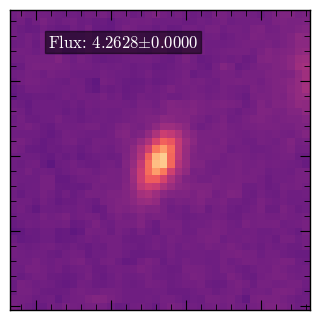

In [56]:
with fits.open('../../phot/color_hst_12197_06_wfc3_ir_f164n_f160w_sci.fits') as hdul:
    header = hdul[0].header
    data = hdul[0].data
    wcs = WCS(header)

data = data.astype(np.float32)
data_swapped = data[1]
target_coord = SkyCoord(RA_DEG, DEC_DEG,unit='deg', frame='icrs')
target_xy = target_coord.to_pixel(wcs, origin=0)
px, py = target_xy[0], target_xy[1]
bkg = sep.Background(data_swapped)
data_sub = data_swapped - bkg.back() 

radius_pix = 5
flux, fluxerr, flag = sep.sum_circle(data_sub, [px], [py],radius_pix)

fig,ax=pf.create_plot()
m, s = np.nanmean(data_sub), np.nanstd(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='magma',vmin=-.1, vmax=.2, origin='lower')

# --- MODIFICATION: Add flux as text to the plot ---
# Format the text string with the flux and its error.
flux_text = fr"Flux: {flux[0]:.4f}$\pm${fluxerr[0]:.4f}"
# Place the text in the top-left corner of the zoomed view.
# We use px and py to position it relative to the image content.
ax.text(px - 15, py + 15, flux_text, color='white', fontsize=12,
        bbox=dict(facecolor='black', alpha=0.5, pad=2))
# --- END MODIFICATION ---


ax.set_xlim(px - 20, px + 20)
ax.set_ylim(py - 20, py + 20)
ax.set_xticklabels([])
ax.set_yticklabels([])

pf.fix_plot([ax])

/Users/thardy/Documents/durham/eelgs/.venv/lib/python3.13/site-packages/matplotlib/colors.py:2294: RuntimeWarning: invalid value encountered in subtract
  resdat -= vmin


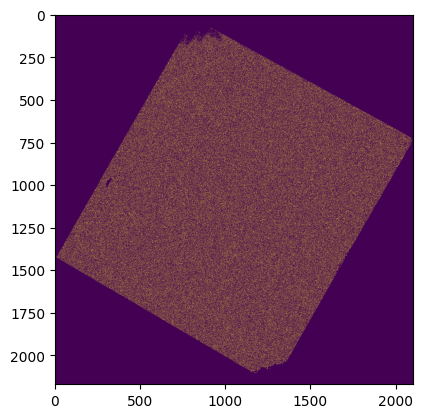

In [29]:
plt.imshow(data_swapped, vmax=1, vmin=0)

In [27]:
flux

array([-2.46869191e+36])

In [57]:
flux_units = header['BUNIT']

In [58]:
flux_units

'ELECTRONS/S'

In [65]:
header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / number of bits per data pixel                  
NAXIS   =                    3 / number of data axes                            
NAXIS1  =                 2104 / length of data axis 1                          
NAXIS2  =                 2170 / length of data axis 2                          
NAXIS3  =                    3 / length of data axis 3                          
EXTEND  =                    T / FITS dataset may contain extensions            
COMMENT   FITS (Flexible Image Transport System) format is defined in 'Astronomy
COMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H 
DATE    = '2025-10-16T12:02:15' / file creation date (YYYY-MM-DDThh:mm:ss UT)   
ROOTNAME= 'ibio06auq                         ' / rootname of the observation set
EXPNAME = 'ibio06auq                ' / exposure identifier                     
BUNIT   = 'ELECTRONS/S'     